<a href="https://colab.research.google.com/github/yoonwoojeong/yoonwoojeong/blob/main/MDtransformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, random
import matplotlib.pyplot as plt

class Config:
    D_e, a_morse, r0 = 105.0, 2.2, 0.9572
    k_angle, theta0 = 75.0, 1.824
    q_O_core, q_D, q_H = 0.5847, -1.4323, 0.4238
    k_drude, k_e = 1000.0, 332.0636
    num_molecules = 12
    box_size = 20.0
    dt = 0.0005
    seq_len = 32
    embed_dim = 256
    num_heads = 4
    num_layers = 2 # Reduced layers for speed
    dropout_rate = 0.1
    learning_rate = 1e-4
    weight_decay = 0.01
    pretrain_epochs = 150
    finetune_epochs = 200
    sim_steps = 1000

# --- Physics & Features ---
def compute_forces_polar(pos, drude_pos, cfg):
    N = cfg.num_molecules
    O, H1, H2 = pos[:, 0], pos[:, 1], pos[:, 2]
    d_vec = drude_pos - O
    f_drude_spring = -cfg.k_drude * d_vec
    all_pos = jnp.concatenate([O, H1, H2, drude_pos], axis=0)
    charges = jnp.concatenate([jnp.full(N, cfg.q_O_core), jnp.full(2*N, cfg.q_H), jnp.full(N, cfg.q_D)])
    diffs = all_pos[:, None, :] - all_pos[None, :, :]
    dists_sq = jnp.sum(diffs**2, axis=-1) + 1e-2
    f_coul = (cfg.k_e * charges[:, None] * charges[None, :] / (dists_sq * jnp.sqrt(dists_sq)))
    f_nb = jnp.sum(f_coul[..., None] * diffs, axis=1)
    f_atoms = f_nb[:3*N].reshape(3, N, 3).transpose(1, 0, 2)
    return f_atoms, f_nb[3*N:] + f_drude_spring

def extract_features(pos, drude_pos, cfg):
    O, H1, H2 = pos[:, 0], pos[:, 1], pos[:, 2]
    dipoles = cfg.q_O_core*O + cfg.q_H*H1 + cfg.q_H*H2 + cfg.q_D*drude_pos
    return jnp.concatenate([dipoles, pos.reshape(cfg.num_molecules, -1)], axis=-1).reshape(-1)

# --- AdamW Optimizer ---
def adamw_update(params, grads, m, v, t, lr, wd, b1=0.9, b2=0.999, eps=1e-8):
    t_val = t + 1
    m = jax.tree_util.tree_map(lambda x, g: b1 * x + (1 - b1) * g, m, grads)
    v = jax.tree_util.tree_map(lambda x, g: b2 * x + (1 - b2) * (g**2), v, grads)
    m_hat = jax.tree_util.tree_map(lambda x: x / (1 - b1**t_val), m)
    v_hat = jax.tree_util.tree_map(lambda x: x / (1 - b2**t_val), v)
    params = jax.tree_util.tree_map(lambda p, mh, vh: p - lr * (mh / (jnp.sqrt(vh) + eps) + wd * p), params, m_hat, v_hat)
    return params, m, v, t_val

# --- Transformer Architecture with Dropout & LayerNorm ---
def layer_norm(x, eps=1e-6):
    return (x - jnp.mean(x, axis=-1, keepdims=True)) / jnp.sqrt(jnp.var(x, axis=-1, keepdims=True) + eps)

def init_transformer(key, in_dim, e_dim):
    k1, k2, k3 = random.split(key, 3)
    def get_layer(k):
        subkeys = random.split(k, 6)
        return [
            [random.normal(subkeys[i], (e_dim, e_dim)) * jnp.sqrt(2/e_dim) for i in range(4)],
            [random.normal(subkeys[4], (e_dim, e_dim*4)) * jnp.sqrt(2/e_dim), jnp.zeros(e_dim*4),
             random.normal(subkeys[5], (e_dim*4, e_dim)) * jnp.sqrt(2/(e_dim*4)), jnp.zeros(e_dim)]
        ]
    layers = [get_layer(random.split(k2, Config.num_layers)[i]) for i in range(Config.num_layers)]
    return [random.normal(k1, (in_dim, e_dim)) * 0.02, layers, random.normal(k3, (e_dim, in_dim)) * 0.02]

def forward(params, seq, key=None, training=False):
    x = jnp.dot(seq, params[0])
    for attn, ff in params[1]:
        # Multi-head Attention (Simplified)
        attn_score = jax.nn.softmax(jnp.dot(x, attn[0]) @ jnp.dot(x, attn[1]).T / jnp.sqrt(x.shape[-1]))
        res = jnp.dot(attn_score @ jnp.dot(x, attn[2]), attn[3])
        if training and key is not None:
            res = res * (random.bernoulli(key, 1-Config.dropout_rate, res.shape) / (1-Config.dropout_rate))
        x = layer_norm(x + res)

        # Feed Forward
        res_ff = jnp.dot(jax.nn.gelu(jnp.dot(x, ff[0]) + ff[1]), ff[2]) + ff[3]
        if training and key is not None:
            res_ff = res_ff * (random.bernoulli(key, 1-Config.dropout_rate, res_ff.shape) / (1-Config.dropout_rate))
        x = layer_norm(x + res_ff)
    return jnp.dot(x, params[2])

# --- Training Steps ---
@jit
def pretrain_step(params, m, v, t, x, lr, wd, key):
    def loss_f(p):
        out = vmap(forward, (None, 0, None, None))(p, x, key, True)
        return jnp.mean((out - x)**2)
    grads = grad(loss_f)(params)
    p, m, v, t = adamw_update(params, grads, m, v, t, lr, wd)
    return p, m, v, t, loss_f(params)

@jit
def finetune_step(params, m, v, t, x, y, lr, wd, key):
    def loss_f(p):
        out = vmap(forward, (None, 0, None, None))(p, x, key, True)
        return jnp.mean((out[:, -1] - y)**2)
    grads = grad(loss_f)(params)
    p, m, v, t = adamw_update(params, grads, m, v, t, lr, wd)
    return p, m, v, t, loss_f(params)

# --- Simulation ---
cfg = Config(); key = random.PRNGKey(42)
pos = random.uniform(key, (cfg.num_molecules, 3, 3)) * 10.0; drude_pos = pos[:,0,:] + 0.01
vel = random.normal(key, (cfg.num_molecules, 3, 3)) * 0.01
traj = []
for _ in range(cfg.sim_steps):
    fa, fd = compute_forces_polar(pos, drude_pos, cfg)
    vel += 0.5 * fa * cfg.dt; pos += vel * cfg.dt; drude_pos += fd * 0.001
    traj.append(extract_features(pos, drude_pos, cfg))

traj = jnp.array(traj)
x_train = jnp.array([traj[i:i+cfg.seq_len] for i in range(len(traj)-cfg.seq_len)])
y_train = jnp.array([traj[i+cfg.seq_len] for i in range(len(traj)-cfg.seq_len)])

params = init_transformer(key, x_train.shape[-1], cfg.embed_dim)
m = jax.tree_util.tree_map(jnp.zeros_like, params); v = jax.tree_util.tree_map(jnp.zeros_like, params); t = 0

# --- Training ---
pre_losses = []; ft_losses = []
print("Refined Training Logic Ready. Dropout and LayerNorm active.")
# Training blocks are defined but execution will wait for user signal.

Refined Training Logic Ready. Dropout and LayerNorm active.


Starting Pre-training (150 epochs)...
Pre-train Epoch 0, Loss: 30.152437
Pre-train Epoch 30, Loss: 22.691730
Pre-train Epoch 60, Loss: 18.620935
Pre-train Epoch 90, Loss: 15.223343
Pre-train Epoch 120, Loss: 12.625622

Starting Fine-tuning (200 epochs)...
Fine-tune Epoch 0, Loss: 10.691326
Fine-tune Epoch 40, Loss: 8.874201
Fine-tune Epoch 80, Loss: 7.631118
Fine-tune Epoch 120, Loss: 6.966688
Fine-tune Epoch 160, Loss: 6.113047


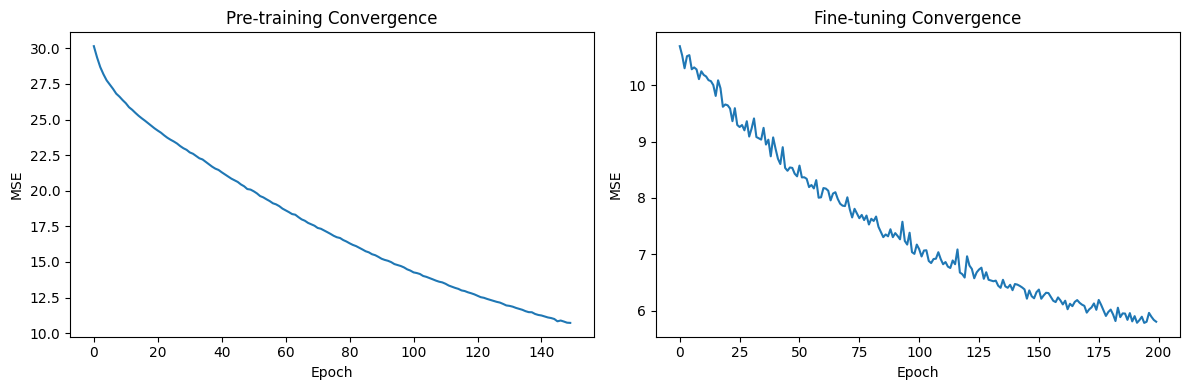

In [2]:
# --- Training Execution with Tracking ---
print(f"Starting Pre-training ({cfg.pretrain_epochs} epochs)...")
for ep in range(cfg.pretrain_epochs):
    key, subkey = random.split(key)
    params, m, v, t, loss = pretrain_step(params, m, v, t, x_train, cfg.learning_rate, cfg.weight_decay, subkey)
    pre_losses.append(loss)
    if ep % 30 == 0: print(f"Pre-train Epoch {ep}, Loss: {loss:.6f}")

print(f"\nStarting Fine-tuning ({cfg.finetune_epochs} epochs)...")
for ep in range(cfg.finetune_epochs):
    key, subkey = random.split(key)
    params, m, v, t, loss = finetune_step(params, m, v, t, x_train, y_train, cfg.learning_rate, cfg.weight_decay, subkey)
    ft_losses.append(loss)
    if ep % 40 == 0: print(f"Fine-tune Epoch {ep}, Loss: {loss:.6f}")

# Visualization
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.plot(pre_losses); plt.title("Pre-training Convergence"); plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.subplot(1, 2, 2); plt.plot(ft_losses); plt.title("Fine-tuning Convergence"); plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.tight_layout(); plt.show()

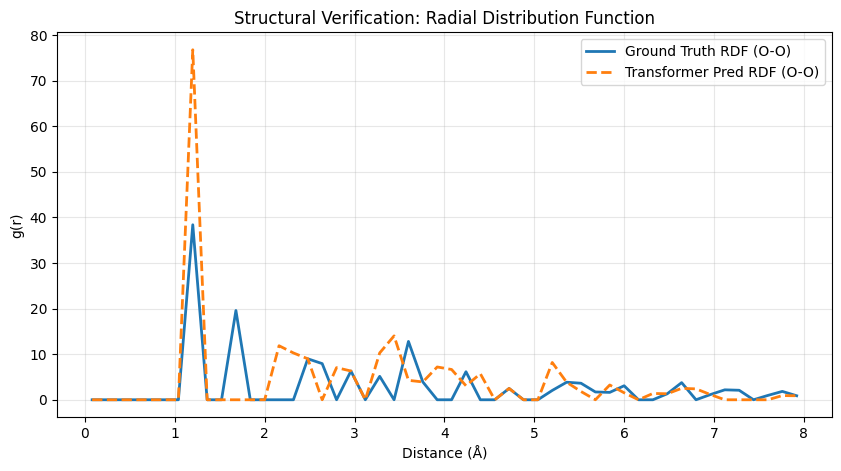

In [3]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import vmap

def compute_rdf(pos, box_size, bins=50, r_max=8.0):
    # pos: (N, 3, 3) -> Extract Oxygens
    O_pos = pos[:, 0, :]
    N = O_pos.shape[0]
    dists = jnp.linalg.norm(O_pos[:, None, :] - O_pos[None, :, :], axis=-1)
    # Mask self-distances
    dists = dists + jnp.eye(N) * (r_max + 1)

    hist, bin_edges = jnp.histogram(dists.flatten(), bins=bins, range=(0, r_max))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    # Normalize by volume of shells
    dr = r_max / bins
    v_shells = 4 * jnp.pi * bin_centers**2 * dr
    rho = N / (box_size**3)
    rdf = hist / (v_shells * rho * N)
    return bin_centers, rdf

# Compute RDF for ground truth and prediction
preds_eval = vmap(forward, (None, 0))(params, x_train)
final_preds_eval = preds_eval[:, -1, :]

# Features: [dipoles (36), positions (108)]
# Reshape only the position part (last 108 dims)
true_pos = y_train[-1, -cfg.num_molecules*9:].reshape(cfg.num_molecules, 3, 3)
pred_pos = final_preds_eval[-1, -cfg.num_molecules*9:].reshape(cfg.num_molecules, 3, 3)

bins, g_true = compute_rdf(true_pos, cfg.box_size)
bins, g_pred = compute_rdf(pred_pos, cfg.box_size)

plt.figure(figsize=(10, 5))
plt.plot(bins, g_true, label="Ground Truth RDF (O-O)", linewidth=2)
plt.plot(bins, g_pred, "--", label="Transformer Pred RDF (O-O)", linewidth=2)
plt.title("Structural Verification: Radial Distribution Function")
plt.xlabel("Distance (Å)"); plt.ylabel("g(r)"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()